# Ray Calculation

Current step as of Fri Aug 7: Seems to be a units issue or some scale problem for the IAT. Gets bigger instead of smaller

In [1]:
import numpy as np
from astropy import units as u

In [2]:
pwd

'/Users/ibehbehani/csm_pipeline'

In [3]:
import csv

csm_2d_density_list = []
with open("saved_data/csm_2d_density.csv") as csvfile:
    reader = csv.reader(csvfile, quoting=csv.QUOTE_NONNUMERIC) # change contents to floats
    for row in reader: # each row is a list
        csm_2d_density_list.append(row)

In [4]:
csm_2d_density = np.array(csm_2d_density_list)


In [5]:
csm_2d_density[np.isnan(csm_2d_density)] = 0



In [6]:
csm_2d_density.shape

(1000, 1000)

In [7]:
from matplotlib import pyplot as plt

In [8]:
csm_2d_density[499,499]

np.float64(0.0)

In [9]:
# get ready to crop out all of the nan vals
center_x = 499
center_y = 499
pix_size_arcsec = 0.005*u.arcsec

In [10]:
lines = 201
points = 100

In [11]:
a=440
b=560
#moving center for cropped image
center_interp = int(csm_2d_density[a:b,a:b].shape[0]/2-1)
center_interp

59

Text(0, 0.5, '$\\Delta$ Dec (arc)')

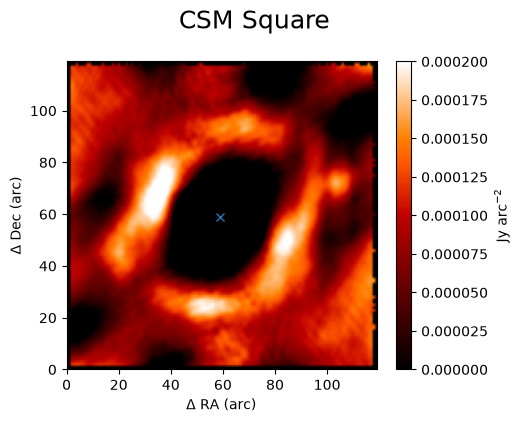

In [12]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)



im = ax.pcolormesh(csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

# ax.set_xlim(a,b)
# ax.set_ylim(a,b)
ax.plot(center_x-a,center_y-a,'x')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [13]:
import sys

In [14]:
np.set_printoptions(threshold=sys.maxsize)

Text(0, 0.5, '$\\Delta$ Dec (arc)')

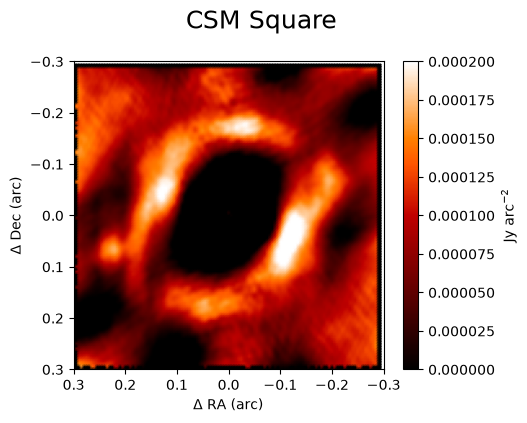

In [15]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1[a:b],yaxis1[a:b],csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

Text(0, 0.5, '$\\Delta$ Dec (arc)')

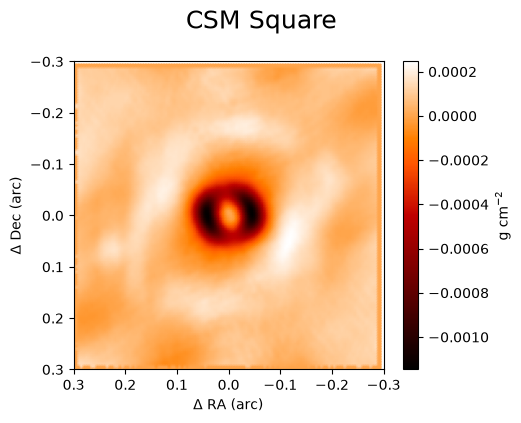

In [16]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1[a:b],yaxis1[a:b],csm_2d_density[a:b,a:b], cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

Text(0, 0.5, '$\\Delta$ Dec (arc)')

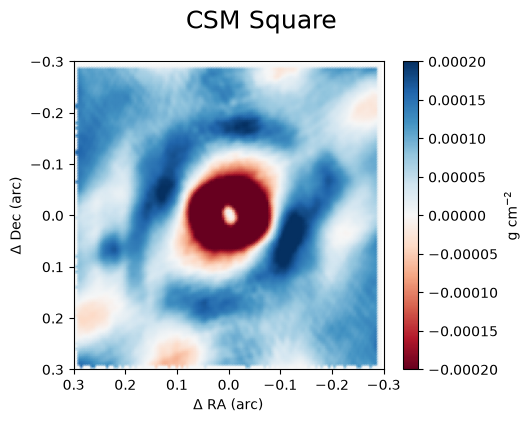

In [17]:
maxx= -0.3
minn = -1*maxx

figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis1[a:b],yaxis1[a:b],csm_2d_density[a:b,a:b], cmap='RdBu',shading="gouraud", vmin = -2e-4, vmax = 2e-4)

ax.set_xlim(minn, maxx)
ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

In [18]:
from radial_interpolation import *

hello again


59 59 0.005 arcsec True


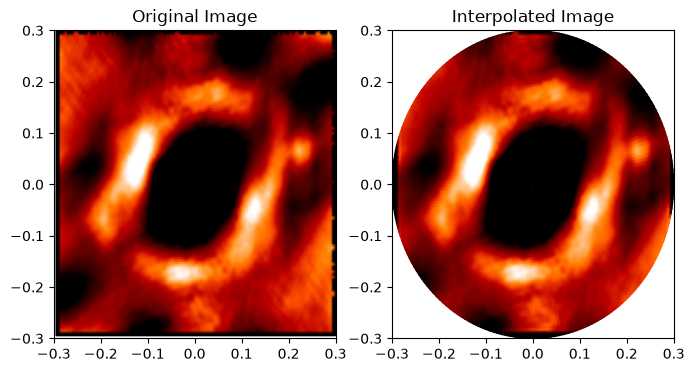

In [19]:
x_grid,y_grid,interp_csm = radial_interp(csm_2d_density[a:b,a:b], center_interp,center_interp,
              n_lines = lines, n_pts = points, pix_arc = pix_size_arcsec,plot_bool=True,vmax=0.0002)

In [20]:
np.min(interp_csm)

np.float64(-0.001146990135269833)

In [21]:
interp_csm.shape

(201, 100)

In [22]:
center_x

499

Text(0.5, 1.0, 'Interpolated Image')

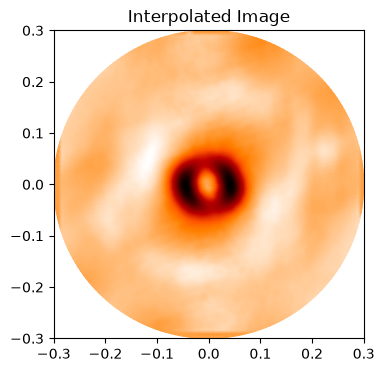

In [23]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(4,4))
xaxis = x_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# rnge = 0.3
# ax.set_xlim(-rnge,rnge)
# ax.set_ylim(-rnge,rnge)


ax.set_title("Interpolated Image")

/var/folders/bd/zqhz_9jx7gn5z5xnr8ynvz5h0000gn/T/ipykernel_30262/506448537.py:12: UserWarning: Adding colorbar to a different Figure <Figure size 500x400 with 2 Axes> than <Figure size 500x400 with 2 Axes> which fig.colorbar is called on.
  figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')


Text(0.5, 1.0, 'Zeroed Out Image')

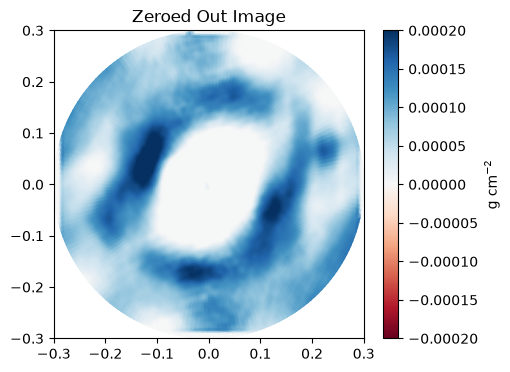

In [24]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(5,4))
xaxis = x_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
yaxis = y_grid*pix_size_arcsec.value-(center_interp*pix_size_arcsec.value)
interp_temp = interp_csm.copy()
interp_temp[interp_temp<0]=0
im = ax.pcolormesh(xaxis, yaxis, interp_temp,cmap='RdBu',shading="gouraud", vmin = -2e-4, vmax = 2e-4)

rnge = 0.3
ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)

figure.colorbar(im,ax=ax, label=r'g cm$^{-2}$')
ax.set_title("Zeroed Out Image")

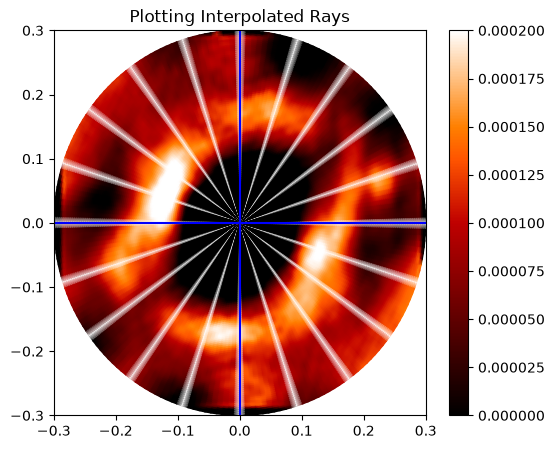

In [25]:
plot_rays(x_grid,y_grid,interp_csm,vmax=0.0002)


# Inverse Abel Transform

In [26]:
from abel import do_abel

In [27]:
from radial import sm

In [28]:
radius_2d_arc = np.array([[0.0]*xaxis.shape[1]]*xaxis.shape[0])
#fill pc array of radii
for i in range(xaxis.shape[0]):
        for j in range(xaxis.shape[1]):
            c = (xaxis[i,j])**2+(yaxis[i,j])**2
            radius_2d_arc[i,j] = np.sqrt(c)

            # c = (center_interp-np.abs(xaxis[i,j]))**2+(center_interp-np.abs(yaxis[i,j]))**2
            # radius_2d_arc[i,j] = np.sqrt(c)

In [29]:
x_pc = sm(168,xaxis)*u.pc
y_pc = sm(168,yaxis)*u.pc

In [30]:
radius_2d_pc = sm(168,radius_2d_arc)*u.pc

Text(0, 0.5, '$\\Delta$ Dec (arc)')

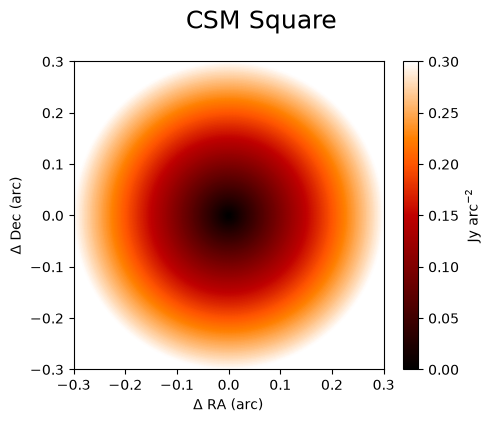

In [31]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(xaxis,yaxis,radius_2d_arc, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ RA (arc)' , size = 10)
ax.set_ylabel(r'$\Delta$ Dec (arc)' , size = 10)

Text(0, 0.5, '$\\Delta$ (pc))')

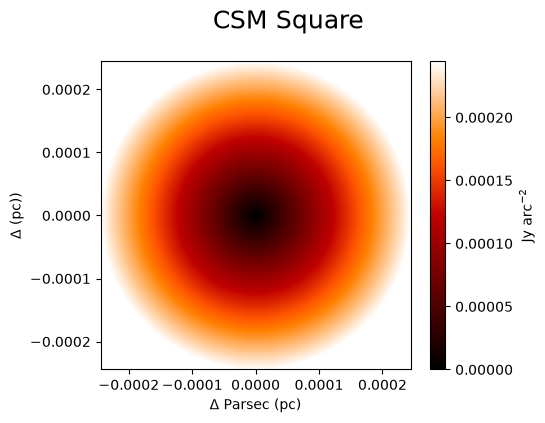

In [32]:
figure,ax = plt.subplots(nrows = 1, ncols=1, figsize = (5,4))#, subplot_kw={'projection': wcs})
figure.suptitle("CSM Square", fontsize = 18, y=1.01)

# xaxis1 = range(csm_2d_density.shape[0])*pix_size_arcsec-(center_x*pix_size_arcsec)
# yaxis1 = range(csm_2d_density.shape[1])*pix_size_arcsec-(center_y*pix_size_arcsec)

im = ax.pcolormesh(x_pc,y_pc,radius_2d_pc.value, cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

# ax.set_xlim(minn, maxx)
# ax.set_ylim(minn, maxx)

figure.colorbar(im,ax=ax, label=r'Jy arc$^{-2}$')

ax.set_xlabel(r'$\Delta$ Parsec (pc)' , size = 10)
ax.set_ylabel(r'$\Delta$ (pc))' , size = 10)

In [33]:
def do_abel_2(F_arr,s,med):
    '''
    F = radial profile of surface density
    s = radii corresponding with radial profile
    med = background median- sets all neg values in F array to bkg median
    '''
    #print(F_arr)
    #integrands = np.zeros(len(s))
    #med = med/10
    F = F_arr.copy() # copy density array to prevent overwriting
    F[F<0] = 0#med/1000 # turn negative values into background 0 or median
    dF_ds = np.gradient(F,s) 

    # c =  8#correction

    # f_r = np.zeros(len(s)-c)
    # r_arr = np.zeros(len(s)-c)
    
    # for i in range(len(s)-c):
    
    f_r = np.zeros(len(s))
    r_arr = np.zeros(len(s))
    
    for i in range(len(s)-1):
        
        r = (s[i]+s[i+1])/2 # set r values (3D radial coords) to s (on sky radius) bin centers
        r_arr[i] = r                    # curtails potential div by zero issues

        
        # integrate from r to highest radial value
        integ = np.trapezoid(dF_ds[i+1:]/ np.sqrt(s[s>r]**2-r**2),s[s>r])
        
        # multiply integral result by -1/pi coefficient
        f_r[i]= (-1/np.pi)* integ # integrate from r to highest radial value

    print("\n",i)
    print('f_r len',len(f_r))
    print('r_arr len', len(r_arr))

    print('f_r zeros', np.count_nonzero(f_r==0))
    print('r_arr zeros', np.count_nonzero(r_arr==0))


    return f_r, dF_ds

In [34]:
csm_abel = []
r_arr = np.zeros(len(interp_csm[i,:]))
row = np.zeros(len(interp_csm[i,:]))
radius_abel_arc = []
x_abel_arc = [] # x data assocated w abel transformed data
y_abel_arc = []
m = 0
all_integrands = []
med_dens = 8.7055651*10**-8 #csm median density

df_ds = [] #df/ds filled list
for i in range(len(interp_csm[:,0])):
    #print('i',i)
    row = np.zeros(len(interp_csm[i,:]))

    row,df_ds_temp = do_abel_2(interp_csm[i,:],(radius_2d_pc[i,:].to(u.cm)).value,med_dens/10)
    #print(df_ds_temp.shape)

    df_ds.append(df_ds_temp)
    csm_abel.append(row)



 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100
f_r zeros 2
r_arr zeros 1

 98
f_r len 100
r_arr len 100


In [35]:
csm_abel = np.array(csm_abel)

In [36]:
df_ds_array = np.array(df_ds)

In [37]:
c=8

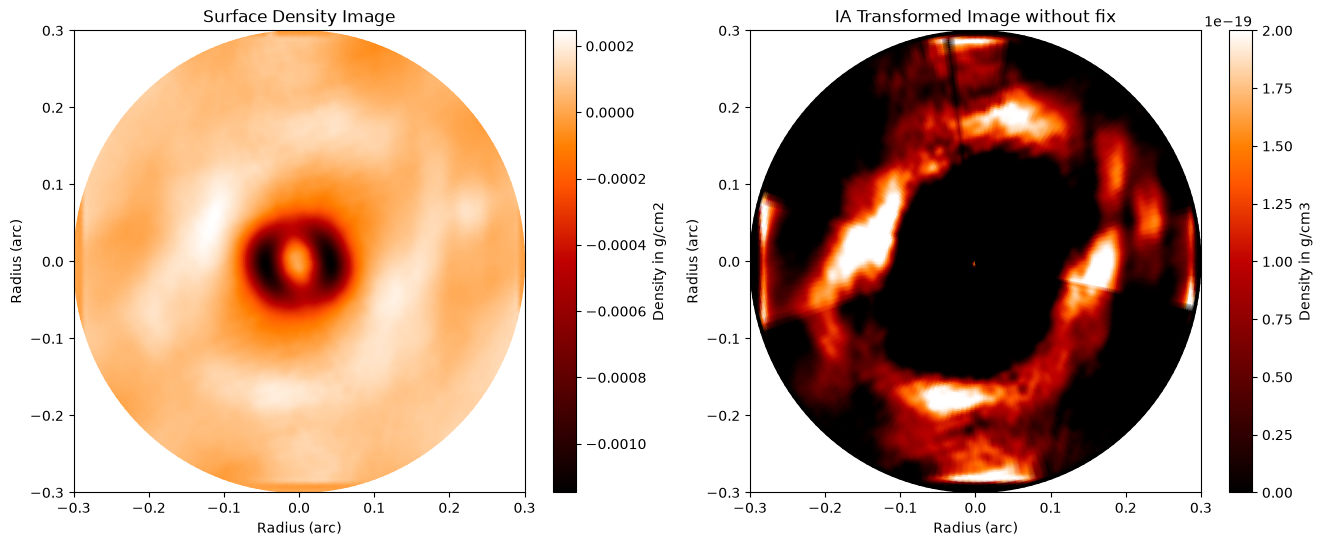

In [38]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_csm,cmap='gist_heat',shading="gouraud")#, vmin = 0, vmax = 0.0002)

rnge = 0.3
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Surface Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image
c=1
#im1 = ax[1].pcolormesh(xaxis[:,0:-c], yaxis[:,0:-c], csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)
im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading="gouraud", vmin = 0, vmax = 2e-19)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image without fix")
fig.colorbar(im1,label = "Density in g/cm3")

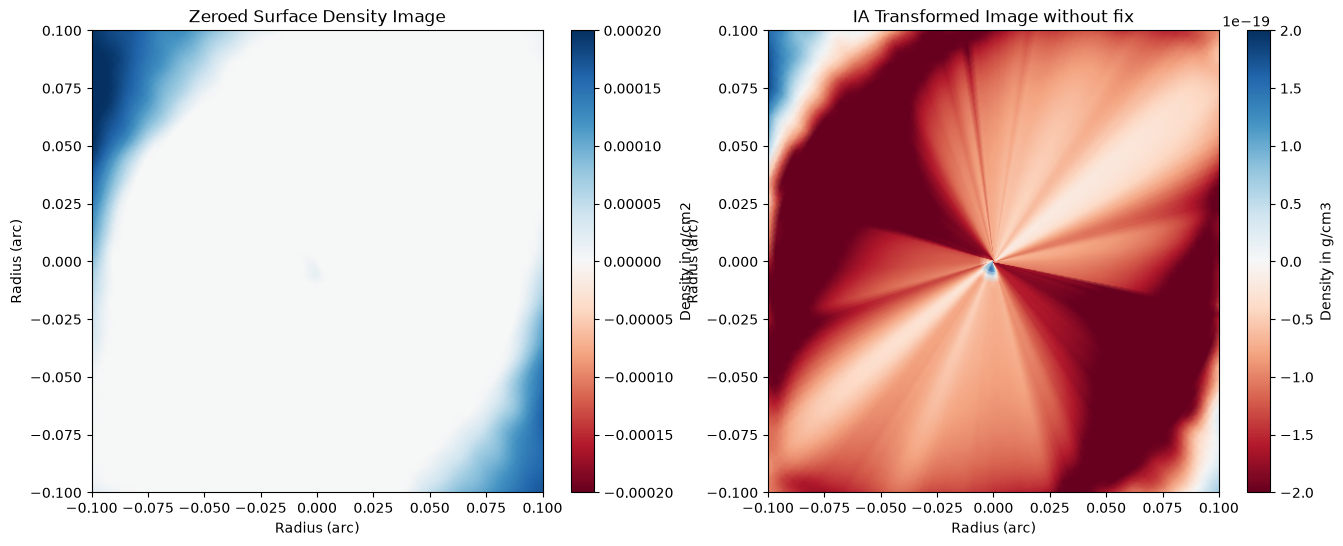

In [39]:
fig, ax = plt.subplots(nrows=1, ncols=2,figsize=(16,6))

im0 = ax[0].pcolormesh(xaxis, yaxis, interp_temp,cmap='RdBu',shading="gouraud", vmin = -2e-4, vmax = 0.0002)

rnge = 0.1
ax[0].set_xlim(-rnge,rnge)
ax[0].set_ylim(-rnge,rnge)
ax[0].set_xlabel("Radius (arc)")
ax[0].set_ylabel("Radius (arc)")

ax[0].set_title("Zeroed Surface Density Image")
fig.colorbar(im0,label = "Density in g/cm2")

### abel image

#im1 = ax[1].pcolormesh(xaxis[:,0:-c], yaxis[:,0:-c], csm_abel,cmap='RdBu',shading="gouraud", vmin = -2e-19, vmax = 2e-19)
im1 = ax[1].pcolormesh(xaxis, yaxis, csm_abel,cmap='RdBu',shading="gouraud", vmin = -2e-19, vmax = 2e-19)

ax[1].set_xlim(-rnge,rnge)
ax[1].set_ylim(-rnge,rnge)
ax[1].set_xlabel("Radius (arc)")
ax[1].set_ylabel("Radius (arc)")


ax[1].set_title("IA Transformed Image without fix")
fig.colorbar(im1,label = "Density in g/cm3")

In [ ]:
#import ipympl

In [ ]:
#%matplotlib ipympl

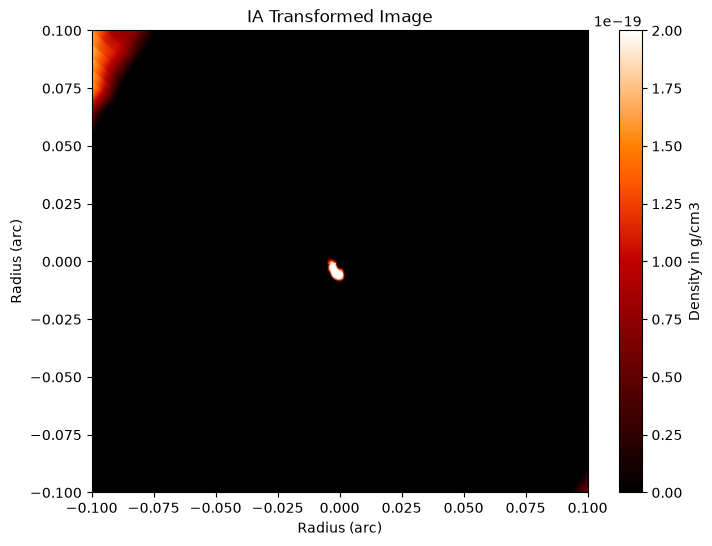

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,6))

im1 = ax.pcolormesh(xaxis, yaxis, csm_abel,cmap='gist_heat',shading= 'gouraud', vmin = 0, vmax = 2e-19)

ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)
ax.set_xlabel("Radius (arc)")
ax.set_ylabel("Radius (arc)")

# q = 0.02
# ax.set_xlim(-q,q)
# ax.set_ylim(-q,q)
ax.set_title("IA Transformed Image")
fig.colorbar(im1,label = "Density in g/cm3")

#fig.canvas.mpl_connect('motion_notify_event', on_plot_hover)           
plt.show()

In [ ]:
from matplotlib import colors


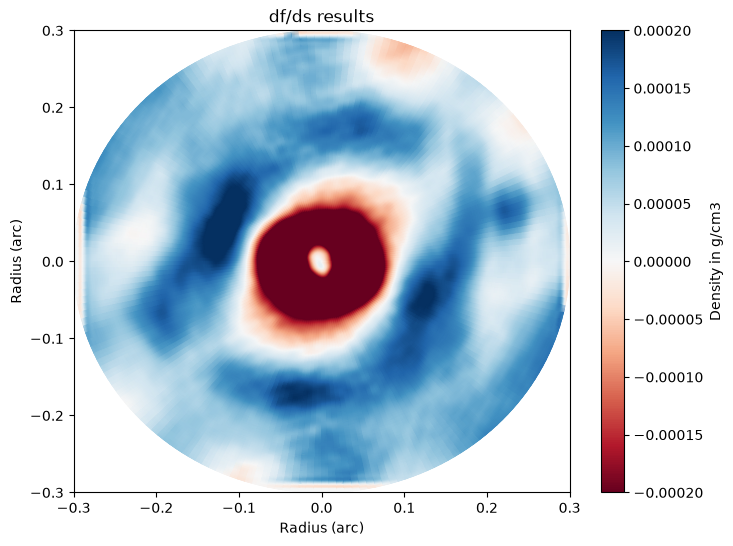

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,6))

im1 = ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='RdBu',shading= 'gouraud', vmin = -2e-4, vmax = 2e-4)

ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)
ax.set_xlabel("Radius (arc)")
ax.set_ylabel("Radius (arc)")

q = 0.3
ax.set_xlim(-q,q)
ax.set_ylim(-q,q)
ax.set_title("df/ds results")
fig.colorbar(im1,label = "Density in g/cm3")

#fig.canvas.mpl_connect('motion_notify_event', on_plot_hover)           
plt.show()

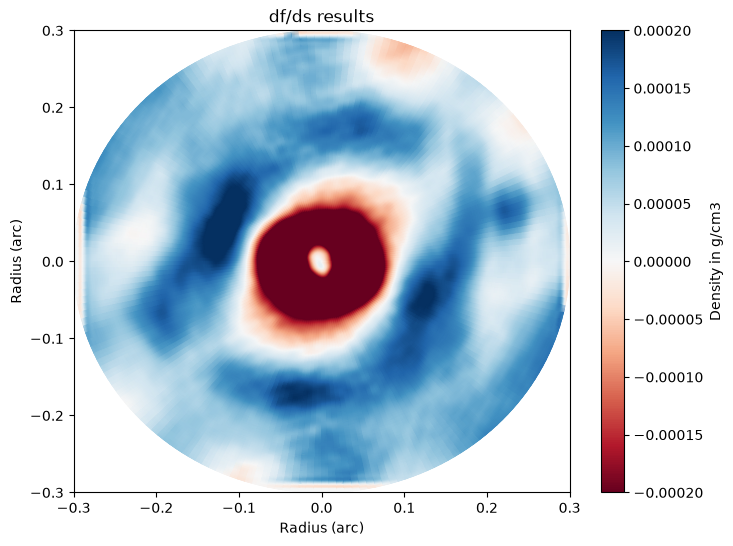

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,6))

im1 = ax.pcolormesh(xaxis, yaxis, interp_csm,cmap='RdBu',shading= 'gouraud',vmin = -2e-4, vmax = 2e-4)#, vmin = -0.0002, vmax = 0.0002)

ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)
ax.set_xlabel("Radius (arc)")
ax.set_ylabel("Radius (arc)")

q = 0.3
ax.set_xlim(-q,q)
ax.set_ylim(-q,q)
ax.set_title("df/ds results")
fig.colorbar(im1,label = "Density in g/cm3")

#fig.canvas.mpl_connect('motion_notify_event', on_plot_hover)           
plt.show()

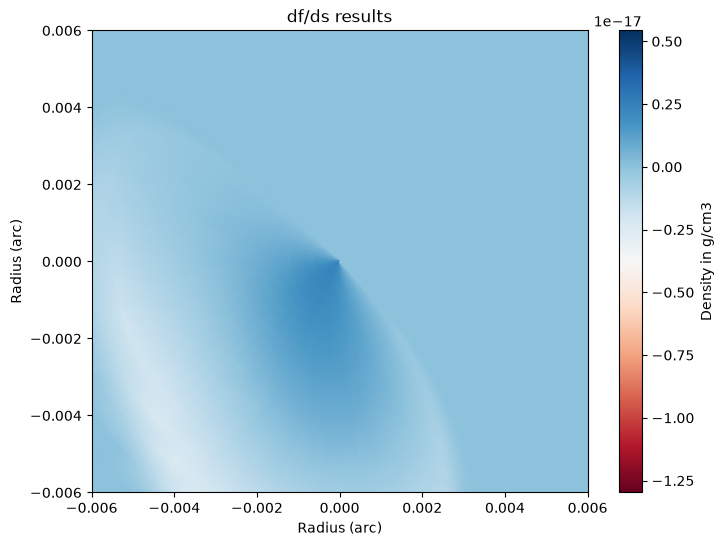

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1,figsize=(8,6))

im1 = ax.pcolormesh(xaxis, yaxis, df_ds_array,cmap='RdBu',shading= 'gouraud')#, vmin = 0, vmax = 2e-19)

ax.set_xlim(-rnge,rnge)
ax.set_ylim(-rnge,rnge)
ax.set_xlabel("Radius (arc)")
ax.set_ylabel("Radius (arc)")

q = 0.006
ax.set_xlim(-q,q)
ax.set_ylim(-q,q)
ax.set_title("df/ds results")
fig.colorbar(im1,label = "Density in g/cm3")

#fig.canvas.mpl_connect('motion_notify_event', on_plot_hover)           
plt.show()

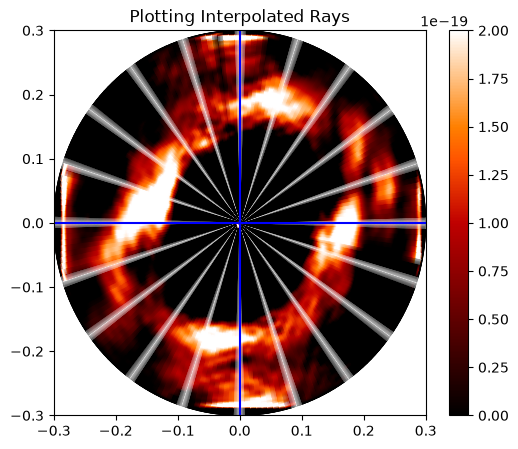

In [ ]:
plot_rays(xaxis, yaxis, csm_abel,vmax = 2e-19,shift = False)